# Classification Foundations and Algorithm Overview

## Purpose of This Notebook

This notebook starts the missing coverage from the uploaded classification materials.

The goal is to build a clear foundation before moving into KNN and the remaining theory topics.

This notebook covers:

1. What supervised learning means
2. What classification means
3. The difference between classification and regression
4. Features `X` and target `y`
5. Class labels
6. Binary, multiclass, and multilabel classification
7. Train/test split
8. Why test data must be unseen
9. Same-distribution and i.i.d. assumptions
10. Classification algorithm families

---

## Source Coverage for This Notebook

| Source | Topic Covered Here |
|---|---|
| `Intro_DTs_KNNs.pdf / .pptx` | Supervised learning, classification basics, train/test split |
| `Intro_DTs_KNNs de.pdf` | German cross-check for supervised learning and classification terms |
| `Classification.pdf` | Classification types, algorithm families, evaluation basics |
| `Milos_Frano_decision_tree.py` | Customer segmentation dataset context and practical classification setup |

---

## Notebook Rule

Each topic will follow this structure:

1. Simple theory
2. Small practical example
3. Interpretation
4. Coverage checkpoint

This notebook is part of the missing Day 7B coverage.

## 1. Classification Foundations

### What Is Supervised Learning?

Supervised learning means the dataset already contains the correct answer.

The model learns from examples where both input data and output labels are known.

Example:

| Customer Information | Correct Segment |
|---|---|
| Age, Profession, Spending Score, Family Size | A |
| Age, Profession, Spending Score, Family Size | B |
| Age, Profession, Spending Score, Family Size | C |

The model studies these examples and learns patterns.

Later, when a new customer comes, the model tries to predict the correct segment.

---

### What Is Classification?

Classification means predicting a **category**.

In our customer segmentation example, the model predicts one of these segment labels:

| Segment |
|---|
| A |
| B |
| C |
| D |

So this is a classification problem because the answer is not a number like sales revenue or price.

The answer is a class/category.

---

### Classification vs Regression

| Problem Type | Predicts | Example |
|---|---|---|
| Classification | Category / class | Predict customer segment A, B, C, or D |
| Regression | Number | Predict customer yearly spending in euros |

Customer segmentation is classification because we predict a segment label.

---

### Features `X` and Target `y`

In machine learning, we usually split the dataset into:

| Symbol | Meaning | Example |
|---|---|---|
| `X` | Input features | Age, Profession, Spending Score |
| `y` | Target label | Segmentation |

The model learns this relationship:

`X → y`

In simple words:

> Customer information goes in, predicted customer segment comes out.

In [1]:
# Code Cell 1A: Simple Classification Example

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a very small example dataset
# ------------------------------------------------------------

# Each row = one customer
# Each column = one piece of customer information
# "Customer_Segment" = the correct answer/class we want to predict

customer_data = pd.DataFrame({
    "Age": [22, 35, 48, 29, 60],
    "Spending_Score": ["Low", "High", "Low", "Average", "High"],
    "Profession": ["Healthcare", "Artist", "Engineer", "Artist", "Lawyer"],
    "Customer_Segment": ["D", "B", "A", "C", "A"]
})

# ------------------------------------------------------------
# Step 2: Separate input features and target label
# ------------------------------------------------------------

# input_features = information we give to the model
# target_label = correct answer the model should learn to predict

input_features = customer_data[[
    "Age",
    "Spending_Score",
    "Profession"
]]

target_label = customer_data["Customer_Segment"]

# ------------------------------------------------------------
# Step 3: Display everything clearly
# ------------------------------------------------------------

print("Full customer data:")
display(customer_data)

print("\nInput features used for prediction:")
display(input_features)

print("\nTarget label we want to predict:")
display(target_label)

Full customer data:


,Age,Spending_Score,Profession,Customer_Segment
0,22,Low,Healthcare,D
1,35,High,Artist,B
2,48,Low,Engineer,A
3,29,Average,Artist,C
4,60,High,Lawyer,A



Input features used for prediction:


,Age,Spending_Score,Profession
0,22,Low,Healthcare
1,35,High,Artist
2,48,Low,Engineer
3,29,Average,Artist
4,60,High,Lawyer



Target label we want to predict:


0    D
1    B
2    A
3    C
4    A
Name: Customer_Segment, dtype: object

### Classification Example Conclusion

In the small example, we separated the data into two parts:

| Object | Meaning |
|---|---|
| `customer_data` | Full example dataset |
| `input_features` | Customer information used for prediction |
| `target_label` | Correct customer segment we want to predict |

The key idea is:

`input_features → model → target_label`

In simple words:

> The model looks at customer information and learns how to predict the customer segment.

This is classification because the target is a category: `A`, `B`, `C`, or `D`.

## 2. Binary, Multiclass, and Multilabel Classification

Classification problems can have different target-label structures.

### Binary Classification

Binary classification means there are only **two possible classes**.

Example:

| Problem | Possible Labels |
|---|---|
| Fraud detection | Fraud / Not Fraud |
| Customer churn | Churn / No Churn |
| Email filtering | Spam / Not Spam |

---

### Multiclass Classification

Multiclass classification means there are **more than two possible classes**, but each row belongs to only one class.

Example:

| Problem | Possible Labels |
|---|---|
| Customer segmentation | A / B / C / D |
| Product category prediction | Electronics / Fashion / Grocery |
| Animal classification | Cat / Dog / Bird |

Our customer segmentation problem is multiclass classification because each customer belongs to one segment: `A`, `B`, `C`, or `D`.

---

### Multilabel Classification

Multilabel classification means one row can have **more than one label at the same time**.

Example:

| Problem | Possible Labels |
|---|---|
| Movie genre prediction | Action + Comedy |
| News article tagging | Politics + Economy |
| Customer interest prediction | Sports + Travel + Technology |

This is different from multiclass classification because one record can have multiple correct answers.

In [5]:
# Code Cell 3A: Load Customer Segmentation Dataset

import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# Step 1: Define the folder where the CSV files are stored
# ------------------------------------------------------------

data_folder = Path("data/customer_segmentation")

# ------------------------------------------------------------
# Step 2: Find all CSV files in the folder
# ------------------------------------------------------------

csv_files = list(data_folder.glob("*.csv"))

print("CSV files found:")
print("-" * 40)

for file in csv_files:
    print(file.name)

# ------------------------------------------------------------
# Step 3: Find the training file
# ------------------------------------------------------------
# We use the file that has "train" in its name.

train_file = None

for file in csv_files:
    if "train" in file.name.lower():
        train_file = file
        break

if train_file is None:
    raise FileNotFoundError("No training CSV file found.")

# ------------------------------------------------------------
# Step 4: Load the training data
# ------------------------------------------------------------
# data = full customer segmentation dataset

data = pd.read_csv(train_file)

# ------------------------------------------------------------
# Step 5: Display basic information
# ------------------------------------------------------------

print("\nDataset loaded successfully.")
print("-" * 40)
print(f"Loaded file:       {train_file.name}")
print(f"Number of rows:    {data.shape[0]}")
print(f"Number of columns: {data.shape[1]}")

display(data.head())

CSV files found:
----------------------------------------
Test.csv
Train.csv

Dataset loaded successfully.
----------------------------------------
Loaded file:       Train.csv
Number of rows:    8068
Number of columns: 11


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


### Real Dataset Loading Conclusion

The real customer segmentation dataset was loaded successfully.

#### Dataset Summary

| Item | Value |
|---|---:|
| Loaded file | `Train.csv` |
| Number of rows | 8,068 |
| Number of columns | 11 |

#### Important Columns

| Column | Meaning |
|---|---|
| `ID` | Customer identifier |
| `Gender` | Customer gender |
| `Ever_Married` | Marital status |
| `Age` | Customer age |
| `Graduated` | Graduation status |
| `Profession` | Customer profession |
| `Work_Experience` | Work experience in years |
| `Spending_Score` | Spending behavior category |
| `Family_Size` | Number of family members |
| `Var_1` | Anonymous customer category |
| `Segmentation` | Target label we want to predict |

This confirms that the real problem is a **multiclass classification problem**, because the target column `Segmentation` contains customer segment labels.

### Classification Types Conclusion

The table shows three common classification types.

| Type | Key Idea |
|---|---|
| Binary classification | The target has only two possible labels |
| Multiclass classification | The target has more than two labels, but each row has only one correct label |
| Multilabel classification | One row can have more than one correct label |

Our customer segmentation problem is **multiclass classification** because each customer belongs to one segment:

`A`, `B`, `C`, or `D`

So in this project:

| Object | Meaning |
|---|---|
| `input_features` | Customer information |
| `target_label` | Customer segment |
| Classification type | Multiclass classification |

In [6]:
# Code Cell 3B: Separate Features and Target

# ------------------------------------------------------------
# Step 1: Define the target column
# ------------------------------------------------------------
# target_column = the column we want to predict

target_column = "Segmentation"

# ------------------------------------------------------------
# Step 2: Create features
# ------------------------------------------------------------
# features = customer information used for prediction
#
# We remove:
# - ID because it is only a customer identifier
# - Segmentation because it is the answer we want to predict

features = data.drop(columns=["ID", target_column])

# ------------------------------------------------------------
# Step 3: Create target
# ------------------------------------------------------------
# target = correct customer segment

target = data[target_column]

# ------------------------------------------------------------
# Step 4: Check the result
# ------------------------------------------------------------

print("Features and target created successfully.")
print("-" * 50)
print(f"features shape: {features.shape}")
print(f"target shape:   {target.shape}")

print("\nTarget labels:")
print(sorted(target.unique()))

print("\nFeatures preview:")
display(features.head())

print("\nTarget preview:")
display(target.head())

Features and target created successfully.
--------------------------------------------------
features shape: (8068, 9)
target shape:   (8068,)

Target labels:
['A', 'B', 'C', 'D']

Features preview:


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4
1,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6
4,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6



Target preview:


0    D
1    A
2    B
3    B
4    A
Name: Segmentation, dtype: object

## 3.1 Target Distribution

The target column is:

`Segmentation`

This column contains the correct customer segment for each customer.

Before building any model, we should check how the target classes are distributed.

This helps us understand:

- how many customers are in each segment,
- whether the classes are balanced or imbalanced,
- whether one segment dominates the dataset.

For this dataset, the classification target has four possible labels:

`A`, `B`, `C`, and `D`

In [ ]:
# Target Distribution

# ------------------------------------------------------------
# Step 1: Count customers in each segment
# ------------------------------------------------------------
# target = the customer segment column
# value_counts() counts how many rows belong to each segment

segment_counts = target.value_counts().sort_index()

# ------------------------------------------------------------
# Step 2: Convert counts into percentages
# ------------------------------------------------------------
# This helps us understand class balance more clearly.

segment_percentages = (
    target.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# Step 3: Create a clean summary table
# ------------------------------------------------------------

# segment_summary combines count and percentage in one table.

segment_summary = pd.DataFrame({
    "segment": segment_counts.index,
    "customer_count": segment_counts.values,
    "percentage": segment_percentages.values
})

# ------------------------------------------------------------
# Step 4: Display the result
# ------------------------------------------------------------

print("Target distribution:")
print("-" * 40)

display(segment_summary)

Target distribution:
----------------------------------------


,segment,customer_count,percentage
0,A,1972,24.44
1,B,1858,23.03
2,C,1970,24.42
3,D,2268,28.11


### Target Distribution Conclusion

The target column `Segmentation` contains four customer segments:

| Segment | Customer Count | Percentage |
|---|---:|---:|
| A | 1,972 | 24.44% |
| B | 1,858 | 23.03% |
| C | 1,970 | 24.42% |
| D | 2,268 | 28.11% |

The dataset is reasonably balanced because no segment is extremely small or extremely dominant.

Segment `D` has the highest share at `28.11%`, while Segment `B` has the lowest share at `23.03%`.

This means accuracy can be used as a basic metric, but we should still check precision, recall, F1-score, and confusion matrix later because this is a multiclass classification problem.

## 3.2 Train/Test Split

In supervised learning, we do not train and test the model on the same data.

We split the dataset into two parts:

| Dataset Part | Meaning |
|---|---|
| Training data | Used by the model to learn patterns |
| Testing data | Used to check how the model performs on unseen customers |

The testing data should behave like future data.

This helps us check whether the model learned useful patterns or only memorized the training data.

### Important Idea

The test data should not be used during model training.

If the model has already seen the test data, the evaluation is not honest.

In [8]:
# Create Train and Test Data

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Step 1: Split features and target into train and test data
# ------------------------------------------------------------
# features = customer information
# target = correct customer segment
#
# train_features = customer information used for learning
# test_features = customer information used for final checking
# train_target = correct answers for training rows
# test_target = correct answers for testing rows
#
# stratify=target keeps the segment distribution similar
# in both train and test data.

train_features, test_features, train_target, test_target = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

# ------------------------------------------------------------
# Step 2: Display the split sizes
# ------------------------------------------------------------

print("Train/test split completed.")
print("-" * 45)
print(f"train_features shape: {train_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"train_target shape:   {train_target.shape}")
print(f"test_target shape:    {test_target.shape}")

Train/test split completed.
---------------------------------------------
train_features shape: (6454, 9)
test_features shape:  (1614, 9)
train_target shape:   (6454,)
test_target shape:    (1614,)


### Train/Test Split Conclusion

The dataset was split into training data and testing data.

| Data Object | Shape | Meaning |
|---|---:|---|
| `train_features` | `(6454, 9)` | Customer information used for learning |
| `test_features` | `(1614, 9)` | Customer information used for final checking |
| `train_target` | `(6454,)` | Correct segment labels for training rows |
| `test_target` | `(1614,)` | Correct segment labels for testing rows |

We used `stratify=target` so that the segment distribution stays similar in both training and testing data.

This is important because the model should learn and be tested on similar class proportions.

In [9]:
# Compare Train and Test Class Balance

# ------------------------------------------------------------
# Step 1: Count segment percentages in training target
# ------------------------------------------------------------
# train_target = correct answers in the training data

train_segment_percentages = (
    train_target
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# Step 2: Count segment percentages in testing target
# ------------------------------------------------------------
# test_target = correct answers in the testing data

test_segment_percentages = (
    test_target
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# Step 3: Combine both into one comparison table
# ------------------------------------------------------------

split_balance = pd.DataFrame({
    "segment": train_segment_percentages.index,
    "train_percentage": train_segment_percentages.values,
    "test_percentage": test_segment_percentages.values
})

# ------------------------------------------------------------
# Step 4: Display the comparison
# ------------------------------------------------------------

print("Train/test segment balance:")
print("-" * 45)

display(split_balance)

Train/test segment balance:
---------------------------------------------


,segment,train_percentage,test_percentage
0,A,24.45,24.41
1,B,23.02,23.05
2,C,24.42,24.41
3,D,28.11,28.13


### Train/Test Balance Conclusion

The segment percentages are almost identical in the training and testing data.

| Segment | Train % | Test % |
|---|---:|---:|
| A | 24.45% | 24.41% |
| B | 23.02% | 23.05% |
| C | 24.42% | 24.41% |
| D | 28.11% | 28.13% |

This confirms that `stratify=target` worked correctly.

The model will learn from training data with a similar segment distribution to the test data.

This makes the evaluation more reliable because the test set is not accidentally biased toward one segment.

## Part 1 Coverage Checkpoint

| Topic | Status |
|---|---|
| Supervised learning | Covered |
| Classification vs regression | Covered |
| Features and target | Covered |
| Binary classification | Covered |
| Multiclass classification | Covered |
| Multilabel classification | Covered |
| Real dataset setup | Covered |
| Target distribution | Covered |
| Train/test split | Covered |
| Stratified split | Covered |

Part 1 is complete.

The customer segmentation problem is now clearly defined as a **supervised multiclass classification problem**.

# Classification Algorithm Families Overview.

## 4. Classification Models: Simple Overview

In this notebook, we are working on a classification problem.

Our question is:

**Can we predict the customer segment from customer information?**

The customer information includes columns such as:

* `Gender`
* `Age`
* `Profession`
* `Work_Experience`
* `Spending_Score`
* `Family_Size`
* `Var_1`

The answer we want to predict is:

`Segmentation`

The possible customer segments are:

`A`, `B`, `C`, and `D`

So, in simple words:

**Customer information goes in, customer segment comes out.**

---

### Why Do We Need This Section?

There are many machine learning models that can be used for classification.

All of them try to predict the correct customer segment, but they do it in different ways.

- Some models use simple rules.

- Some models compare customers with similar customers.

- Some models combine many smaller models.

- Some models learn more complex patterns.

This section gives a simple overview of common classification models.

We are **not training all models here**.

The goal is only to understand where **Decision Trees** and **KNN** fit in the bigger classification family.

---

### Simple Business View

| Model Type          | Simple Thinking Style                           |
| ------------------- | ----------------------------------------------- |
| Decision Tree       | Ask simple yes/no questions                     |
| KNN                 | Find similar customers                          |
| Random Forest       | Ask many decision trees and combine the answers |
| Gradient Boosting   | Build models step by step and improve mistakes  |
| Logistic Regression | Separate groups using a simple border           |
| SVM                 | Find a strong border between groups             |
| Neural Network      | Learn complex patterns using layers             |

For our missing Day 7B work, the most important model is **KNN**, because it was included in the uploaded documents and still needs to be covered properly.


| Analyst Style            | ML Model Example          | How It Thinks                                         |
| ------------------------ | ------------------------- | ----------------------------------------------------- |
| Rule-based analyst       | Decision Tree             | “If age is low and spending is low, maybe Segment D.” |
| Similarity-based analyst | KNN                       | “This customer looks similar to these old customers.” |
| Voting committee         | Random Forest             | “Ask many trees and combine their opinions.”          |
| Error-correcting analyst | Gradient Boosting         | “Fix previous mistakes step by step.”                 |
| Boundary-drawing analyst | Logistic Regression / SVM | “Draw a line/border between groups.”                  |
| Pattern-learning analyst | Neural Network            | “Learn complex hidden patterns from many examples.”   |


In [12]:
# Code Cell 4A: Simple Overview of Classification Models

import pandas as pd

# ------------------------------------------------------------
# Step 1: Create a simple model overview table
# ------------------------------------------------------------
# This table is only for understanding.
# We are not training all these models in this notebook.
#
# Each row explains one classification model in simple business language.

model_overview = pd.DataFrame({
    "model_name": [
        "Logistic Regression",
        "LDA",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "KNN",
        "SVM",
        "Neural Network"
    ],
    "simple_idea": [
        "Separates customer groups using a simple border",
        "Uses group patterns to decide where a customer belongs",
        "Uses simple yes/no questions",
        "Uses many decision trees and combines their answers",
        "Builds models step by step to improve mistakes",
        "Finds similar customers and uses their segment",
        "Finds a strong border between customer groups",
        "Learns complex patterns using connected layers"
    ],
    "customer_example": [
        "Separate customers likely to churn from customers likely to stay",
        "Check which customer group a new customer looks closest to",
        "If Age is low and Spending Score is low, predict Segment D",
        "Many trees vote for the final customer segment",
        "Each new model tries to fix earlier wrong predictions",
        "Find nearby similar customers and predict the common segment",
        "Draw a strong separation between customer segments",
        "Learn hidden customer behavior patterns from many examples"
    ],
    "important_note": [
        "Good simple starting model",
        "Works best when group patterns are clear",
        "Easy to explain to business users",
        "Usually stronger than one decision tree",
        "Often strong for tabular business data",
        "Needs scaling and can be slower during prediction",
        "Powerful but harder to explain",
        "Needs more data and careful tuning"
    ]
})

# ------------------------------------------------------------
# Step 2: Display the overview table
# ------------------------------------------------------------

display(model_overview)

,model_name,simple_idea,customer_example,important_note
0,Logistic Regression,Separates customer groups using a simple border,Separate customers likely to churn from custom...,Good simple starting model
1,LDA,Uses group patterns to decide where a customer...,Check which customer group a new customer look...,Works best when group patterns are clear
2,Decision Tree,Uses simple yes/no questions,"If Age is low and Spending Score is low, predi...",Easy to explain to business users
3,Random Forest,Uses many decision trees and combines their an...,Many trees vote for the final customer segment,Usually stronger than one decision tree
4,Gradient Boosting,Builds models step by step to improve mistakes,Each new model tries to fix earlier wrong pred...,Often strong for tabular business data
5,KNN,Finds similar customers and uses their segment,Find nearby similar customers and predict the ...,Needs scaling and can be slower during prediction
6,SVM,Finds a strong border between customer groups,Draw a strong separation between customer segm...,Powerful but harder to explain
7,Neural Network,Learns complex patterns using connected layers,Learn hidden customer behavior patterns from m...,Needs more data and careful tuning


## 5. Compact Customer Segmentation EDA Recap

Before moving deeper into KNN and other classification concepts, we briefly inspect the customer segmentation dataset.

EDA means **Exploratory Data Analysis**.

The goal is to understand the data before modelling.

In this section, we focus only on a few useful business questions:

1. How are customers distributed across segments?
2. How does age vary across segments?
3. How does spending score vary across segments?
4. How does `Var_1` vary across segments?

This is a compact EDA recap, not a full dashboard.

The purpose is to understand the customer groups before we later apply KNN.

In [13]:
# Code Cell 5A: Create a Clean Segment Summary

# ------------------------------------------------------------
# Step 1: Count customers in each segment
# ------------------------------------------------------------
# target = customer segment column
# This tells us how many customers belong to A, B, C, and D.

segment_count = target.value_counts().sort_index()

# ------------------------------------------------------------
# Step 2: Calculate segment percentage
# ------------------------------------------------------------
# Percentages make it easier to compare segment sizes.

segment_percentage = (
    target
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# Step 3: Combine count and percentage into one table
# ------------------------------------------------------------

segment_table = pd.DataFrame({
    "segment": segment_count.index,
    "customer_count": segment_count.values,
    "percentage": segment_percentage.values
})

# ------------------------------------------------------------
# Step 4: Display the table
# ------------------------------------------------------------

display(segment_table)

,segment,customer_count,percentage
0,A,1972,24.44
1,B,1858,23.03
2,C,1970,24.42
3,D,2268,28.11


### Segment Summary Interpretation

The four customer segments are reasonably balanced.

Segment `D` is the largest group with `2,268` customers, which is `28.11%` of the dataset.

Segment `B` is the smallest group with `1,858` customers, which is `23.03%` of the dataset.

The difference between the largest and smallest segment is not extreme.

This is useful because the model will not be trained on a dataset where one segment completely dominates the others.

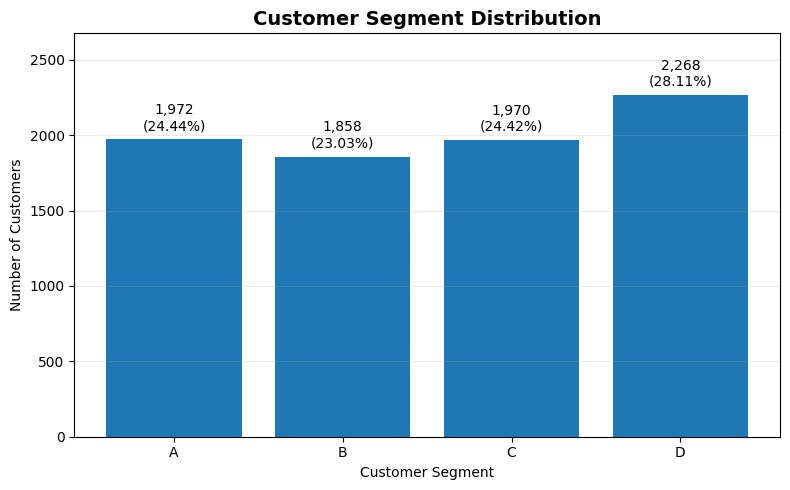

In [14]:
# Code Cell 5B: Segment Distribution Chart

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Step 1: Create the chart area
# ------------------------------------------------------------
# This chart shows how many customers are in each segment.

plt.figure(figsize=(8, 5))

# ------------------------------------------------------------
# Step 2: Create a bar chart
# ------------------------------------------------------------
# segment_table["segment"] = segment names A, B, C, D
# segment_table["customer_count"] = number of customers in each segment

bars = plt.bar(
    segment_table["segment"],
    segment_table["customer_count"]
)

# ------------------------------------------------------------
# Step 3: Add labels above each bar
# ------------------------------------------------------------
# This makes the chart easier to read.

for bar, percentage in zip(bars, segment_table["percentage"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 40,
        f"{int(height):,}\n({percentage}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

# ------------------------------------------------------------
# Step 4: Format the chart
# ------------------------------------------------------------

plt.title(
    "Customer Segment Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.ylim(0, segment_table["customer_count"].max() * 1.18)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### Segment Distribution Chart Interpretation

The chart shows that the four customer segments are fairly close in size.

Segment `D` is the largest segment, but it does not dominate the dataset.

This is useful for classification because the model will not learn from a dataset where one class is extremely larger than the others.

A reasonably balanced target makes the first model evaluation easier to interpret.

Later, when we build KNN, we will still use more than accuracy. We will also check precision, recall, F1-score, and confusion matrix.

## 5.2 Age by Customer Segment

Age is an important customer feature.

Different customer segments may have different age patterns.

For example:

- one segment may contain younger customers,
- another segment may contain older customers,
- some segments may have a wider age range.

In this step, we compare the average age of customers in each segment.

This helps us understand whether age may be useful for predicting the customer segment.

In [16]:
# Code Cell 5C: Average Age by Customer Segment

# ------------------------------------------------------------
# Step 1: Calculate average age for each segment
# ------------------------------------------------------------
# data = full customer dataset
# Segmentation = customer segment
# Age = customer age

age_table = (
    data
    .groupby("Segmentation")["Age"]
    .mean()
    .round(1)
    .reset_index()
)

# ------------------------------------------------------------
# Step 2: Rename columns for clearer output
# ------------------------------------------------------------

age_table.columns = [
    "segment",
    "average_age"
]

# ------------------------------------------------------------
# Step 3: Display the table
# ------------------------------------------------------------

display(age_table)

,segment,average_age
0,A,44.9
1,B,48.2
2,C,49.1
3,D,33.4


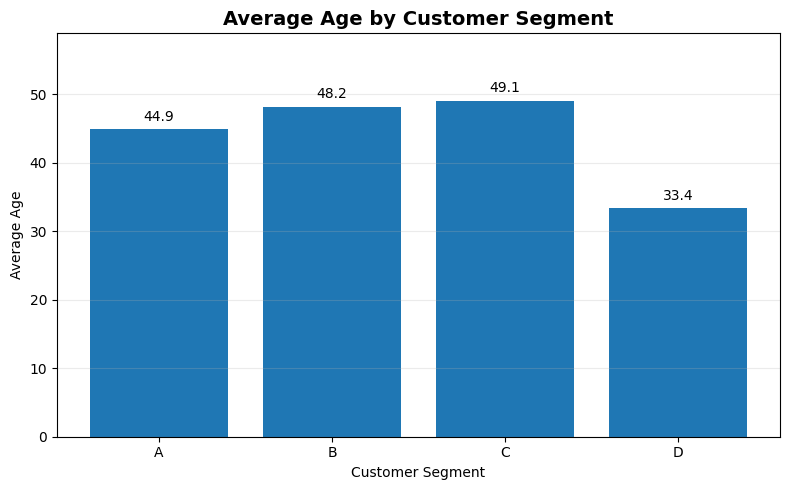

In [17]:
# Code Cell 5D: Average Age by Customer Segment Chart

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Step 1: Create the chart area
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

# ------------------------------------------------------------
# Step 2: Create the bar chart
# ------------------------------------------------------------
# age_table["segment"] = customer segment labels
# age_table["average_age"] = average age for each segment

bars = plt.bar(
    age_table["segment"],
    age_table["average_age"]
)

# ------------------------------------------------------------
# Step 3: Add value labels above each bar
# ------------------------------------------------------------

for bar in bars:
    bar_height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar_height + 0.8,
        f"{bar_height:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# ------------------------------------------------------------
# Step 4: Format the chart
# ------------------------------------------------------------

plt.title(
    "Average Age by Customer Segment",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Age")

plt.ylim(0, age_table["average_age"].max() * 1.20)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 5.3 Spending Score by Customer Segment

`Spending_Score` describes the spending behavior of a customer.

In this dataset, spending score has categories such as:

- `Low`
- `Average`
- `High`

This feature may be useful for classification because different customer segments may show different spending patterns.

In this step, we compare spending score distribution across customer segments.

The goal is to understand whether spending behavior is connected to the customer segment.

In [18]:
# Code Cell 5E: Spending Score by Customer Segment

# ------------------------------------------------------------
# Step 1: Create a count table
# ------------------------------------------------------------
# This table counts how many customers from each segment
# belong to each spending score category.

spending_count_table = pd.crosstab(
    data["Segmentation"],
    data["Spending_Score"]
)

# ------------------------------------------------------------
# Step 2: Create a percentage table
# ------------------------------------------------------------
# Percentages are easier to compare than raw counts.
# Each row adds up to 100%.
#
# Example:
# If Segment A has 60% Low spending customers,
# that means 60% of Segment A customers have Low Spending_Score.

spending_percentage_table = (
    pd.crosstab(
        data["Segmentation"],
        data["Spending_Score"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# Step 3: Display both tables
# ------------------------------------------------------------

print("Spending Score Count Table:")
display(spending_count_table)

print("\nSpending Score Percentage Table:")
display(spending_percentage_table)

Spending Score Count Table:


Spending_Score,Average,High,Low
Segmentation,,,
A,343,271,1358
B,590,384,884
C,903,405,662
D,138,156,1974



Spending Score Percentage Table:


Spending_Score,Average,High,Low
Segmentation,,,
A,17.39,13.74,68.86
B,31.75,20.67,47.58
C,45.84,20.56,33.60
D,6.08,6.88,87.04


### Spending Score by Segment Interpretation

The spending score distribution is different across customer segments.

| Segment | Main Pattern |
|---|---|
| A | Mostly Low Spending |
| B | Mixed, but Low Spending is still the largest group |
| C | Highest share of Average Spending customers |
| D | Very strongly Low Spending |

Segment `D` has the strongest Low Spending pattern, with `87.04%` of customers in the Low category.

Segment `C` has the highest Average Spending share, with `45.84%`.

This suggests that `Spending_Score` may be useful for predicting the customer segment.

For KNN later, this matters because KNN compares customers based on similar feature values. Customers with similar spending behavior may be closer to each other after preprocessing.

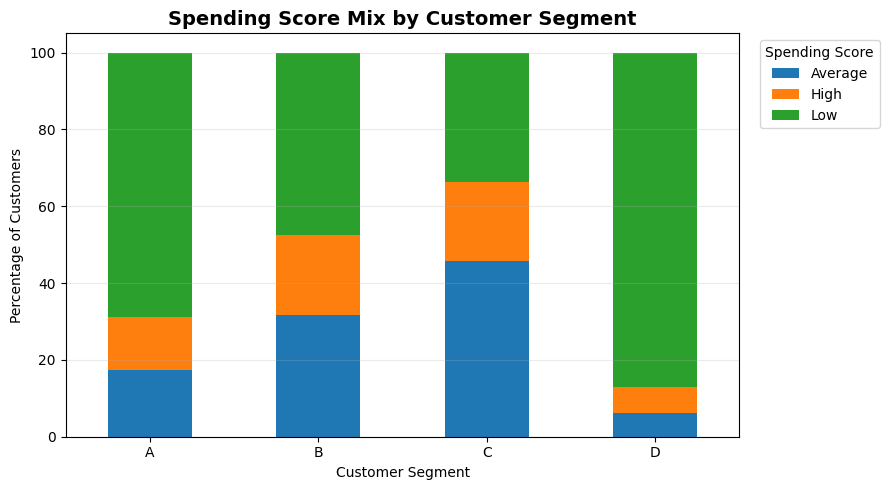

In [19]:
# Code Cell 5F: Spending Score by Customer Segment Chart

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Step 1: Use the percentage table for the chart
# ------------------------------------------------------------
# spending_percentage_table already contains percentage values.
# Each row is one customer segment.
# Each column is one spending score category.

chart_data = spending_percentage_table.copy()

# ------------------------------------------------------------
# Step 2: Create a stacked bar chart
# ------------------------------------------------------------
# This chart shows the spending score mix inside each segment.

ax = chart_data.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

# ------------------------------------------------------------
# Step 3: Format the chart
# ------------------------------------------------------------

plt.title(
    "Spending Score Mix by Customer Segment",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Percentage of Customers")

plt.xticks(rotation=0)
plt.legend(title="Spending Score", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 5.4 Var_1 by Customer Segment

`Var_1` is an anonymous customer category in the dataset.

We do not know its exact business meaning, but it may still be useful for prediction.

In this step, we check how `Var_1` categories are distributed across customer segments.

This helps us understand whether some `Var_1` categories are more common in specific segments.

In [20]:
# Code Cell 5G: Var_1 by Customer Segment

# ------------------------------------------------------------
# Step 1: Create a percentage table
# ------------------------------------------------------------
# This table shows the percentage mix of Var_1 categories
# inside each customer segment.
#
# Each row = one customer segment
# Each column = one Var_1 category
# Each row adds up to 100%

var1_percentage_table = (
    pd.crosstab(
        data["Segmentation"],
        data["Var_1"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# Step 2: Display the table
# ------------------------------------------------------------

print("Var_1 percentage distribution by customer segment:")
display(var1_percentage_table)

Var_1 percentage distribution by customer segment:


Var_1,Cat_1,Cat_2,Cat_3,Cat_4,Cat_5,Cat_6,Cat_7
Segmentation,,,,,,,
A,1.59,4.25,11.42,17.05,0.97,62.11,2.61
B,1.41,5.75,10.08,12.57,1.08,66.78,2.33
C,1.33,5.08,7.90,5.59,0.92,76.76,2.41
D,2.23,5.97,11.54,18.49,1.25,57.77,2.76


### Var_1 by Segment Interpretation

`Var_1` shows different category patterns across customer segments.

The strongest pattern is that `Cat_6` is the most common category in all segments.

| Segment | Cat_6 Share |
|---|---:|
| A | 62.11% |
| B | 66.78% |
| C | 76.76% |
| D | 57.77% |

Segment `C` has the highest `Cat_6` share.

Segment `D` has the lowest `Cat_6` share.

This suggests that `Var_1` may contain useful information for predicting customer segments.

However, since `Var_1` is anonymous, we should treat it carefully in business interpretation. It may help the model, but we cannot explain it as clearly as features like `Age` or `Spending_Score`.

## Part 3 Coverage Checkpoint

This compact EDA section covered the key customer segmentation patterns needed before KNN.

| Topic | Status |
|---|---|
| Segment distribution | Covered |
| Average age by segment | Covered |
| Spending score by segment | Covered |
| Var_1 by segment | Covered |

### Main Findings

1. The target segments are reasonably balanced.
2. Segment `D` has the youngest customers on average.
3. Segment `D` is strongly connected with Low Spending Score.
4. Segment `C` has the highest Average Spending Score share.
5. `Var_1` may contain useful signal, especially through `Cat_6`, but it is harder to explain because it is anonymous.

These patterns help us understand the dataset before building KNN later.

# Notebook 1 Final Summary

This notebook covered the first missing part from the uploaded classification materials.

The focus was on building a clear foundation before moving into the deeper Decision Tree theory and KNN practical notebooks.

## What Was Covered

| Area | Status |
|---|---|
| Supervised learning | Covered |
| Classification vs regression | Covered |
| Features and target | Covered |
| Binary, multiclass, and multilabel classification | Covered |
| Real customer segmentation dataset setup | Covered |
| Target distribution | Covered |
| Train/test split | Covered |
| Stratified split check | Covered |
| Classification model families | Covered |
| Compact customer segmentation EDA | Covered |

## Main Learning Points

The customer segmentation dataset is a supervised multiclass classification problem.

The model will use customer information such as age, profession, spending score, work experience, family size, and anonymous customer categories to predict the customer segment.

The target column is `Segmentation`, and the possible customer segments are `A`, `B`, `C`, and `D`.

The target distribution is reasonably balanced, which makes the first model evaluation easier to interpret.

The compact EDA showed that some features may be useful for prediction:

- Segment `D` has younger customers on average.
- Segment `D` is strongly connected with Low Spending Score.
- Segment `C` has the highest Average Spending Score share.
- `Var_1` may contain useful information, but it is harder to explain because it is anonymous.

## Why This Notebook Matters

This notebook prepares the foundation for the next missing-part notebooks.

Notebook 2 will focus on deeper Decision Tree theory and pruning.

Notebook 3 will focus on KNN, lazy learning, KNN imputation, and model comparison.